Imports

In [54]:
import warnings
warnings.filterwarnings("ignore")

from itertools import product

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import mean_squared_error
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline


Configuration


In [55]:
DATA_PATH = "/content/Steel_industry_data.csv"

RANDOM_SEED = 42
TRAIN_FRACTION = 0.8

NUM_INDUCING_POINTS = 150
MIN_POINTS_PER_GP = 50

LS_GRID = [0.01, 0.02, 0.03, 0.05]
NOISE_GRID = [0.05, 0.10, 0.20]
SV_GRID = [0.50, 1.00, 2.00]

BETA = 0.2
STD_CLIP = 1.5

np.random.seed(RANDOM_SEED)

Load data

In [56]:
df = pd.read_csv(DATA_PATH)

df["date"] = pd.to_datetime(df["date"], dayfirst=True)
df = df.sort_values("date").reset_index(drop=True)

display(df.head())
print(df.shape)
print(df.columns)

,date,Usage_kWh,Lagging_Current_Reactive.Power_kVarh,Leading_Current_Reactive_Power_kVarh,CO2(tCO2),Lagging_Current_Power_Factor,Leading_Current_Power_Factor,NSM,WeekStatus,Day_of_week,Load_Type
0,2018-01-01 00:00:00,3.42,3.46,0.0,0.0,70.30,100.0,0,Weekday,Monday,Light_Load
1,2018-01-01 00:15:00,3.17,2.95,0.0,0.0,73.21,100.0,900,Weekday,Monday,Light_Load
2,2018-01-01 00:30:00,4.00,4.46,0.0,0.0,66.77,100.0,1800,Weekday,Monday,Light_Load
3,2018-01-01 00:45:00,3.24,3.28,0.0,0.0,70.28,100.0,2700,Weekday,Monday,Light_Load
4,2018-01-01 01:00:00,3.31,3.56,0.0,0.0,68.09,100.0,3600,Weekday,Monday,Light_Load


(35040, 11)
Index(['date', 'Usage_kWh', 'Lagging_Current_Reactive.Power_kVarh',
       'Leading_Current_Reactive_Power_kVarh', 'CO2(tCO2)',
       'Lagging_Current_Power_Factor', 'Leading_Current_Power_Factor', 'NSM',
       'WeekStatus', 'Day_of_week', 'Load_Type'],
      dtype='object')


Keep weekday data and create temporal train/test split



In [57]:
df_weekday = df[df["WeekStatus"] == "Weekday"].reset_index(drop=True)

unique_dates = df_weekday["date"].dt.date.unique()
split_date = unique_dates[int(TRAIN_FRACTION * len(unique_dates))]

train_df = df_weekday[df_weekday["date"].dt.date < split_date].reset_index(drop=True)
test_df = df_weekday[df_weekday["date"].dt.date >= split_date].reset_index(drop=True)

print(f"Train rows: {len(train_df)}")
print(f"Test rows:  {len(test_df)}")
print(f"Split date: {split_date}")

print("\nTrain load types:")
print(train_df["Load_Type"].value_counts())

print("\nTest load types:")
print(test_df["Load_Type"].value_counts())

Train rows: 19968
Test rows:  5088
Split date: 2018-10-18

Train load types:
Load_Type
Light_Load      8936
Medium_Load     6304
Maximum_Load    4728
Name: count, dtype: int64

Test load types:
Load_Type
Light_Load      2232
Medium_Load     1632
Maximum_Load    1224
Name: count, dtype: int64


Prepare features and target

In [58]:
X_train_raw = train_df["NSM"].values / 86400.0
X_test_raw = test_df["NSM"].values / 86400.0

y_train_raw = train_df["Usage_kWh"].values
y_test_raw = test_df["Usage_kWh"].values

y_mean = y_train_raw.mean()
y_std = y_train_raw.std()

X_train = X_train_raw.reshape(-1, 1)
X_test = X_test_raw.reshape(-1, 1)

y_train = (y_train_raw - y_mean) / y_std
y_test = (y_test_raw - y_mean) / y_std

load_type_train = train_df["Load_Type"].values
load_type_test = test_df["Load_Type"].values

assert X_train.shape[0] == y_train.shape[0]
assert X_test.shape[0] == y_test.shape[0]

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape:  {X_test.shape}")
print(f"y_train mean: {y_train.mean():.3f}")
print(f"y_train std:  {y_train.std():.3f}")

X_train shape: (19968, 1)
X_test shape:  (5088, 1)
y_train mean: -0.000
y_train std:  1.000


Exploratory plot: training data

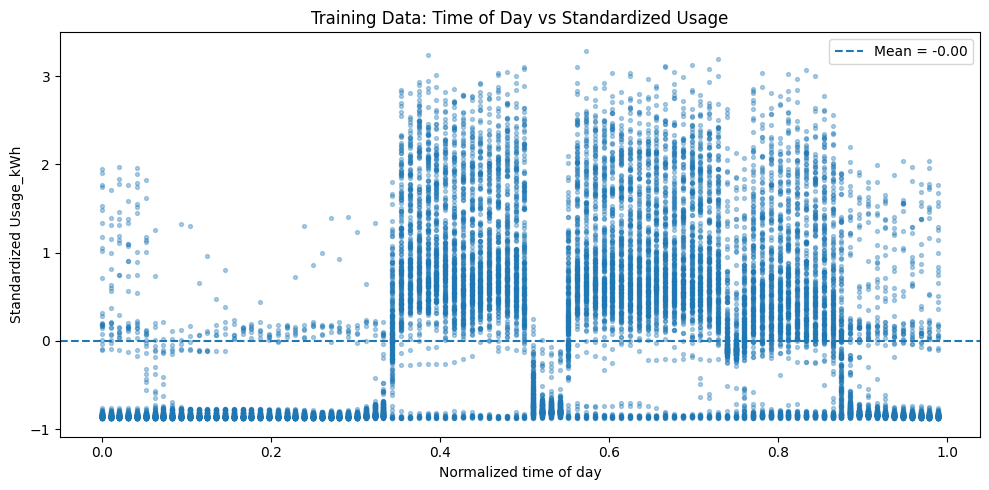

In [59]:
plt.figure(figsize=(10, 5))
plt.scatter(X_train.ravel(), y_train, s=8, alpha=0.35)
plt.axhline(y_train.mean(), linestyle="--", label=f"Mean = {y_train.mean():.2f}")
plt.title("Training Data: Time of Day vs Standardized Usage")
plt.xlabel("Normalized time of day")
plt.ylabel("Standardized Usage_kWh")
plt.legend()
plt.tight_layout()
plt.show()


Exploratory plot: average usage by time of day

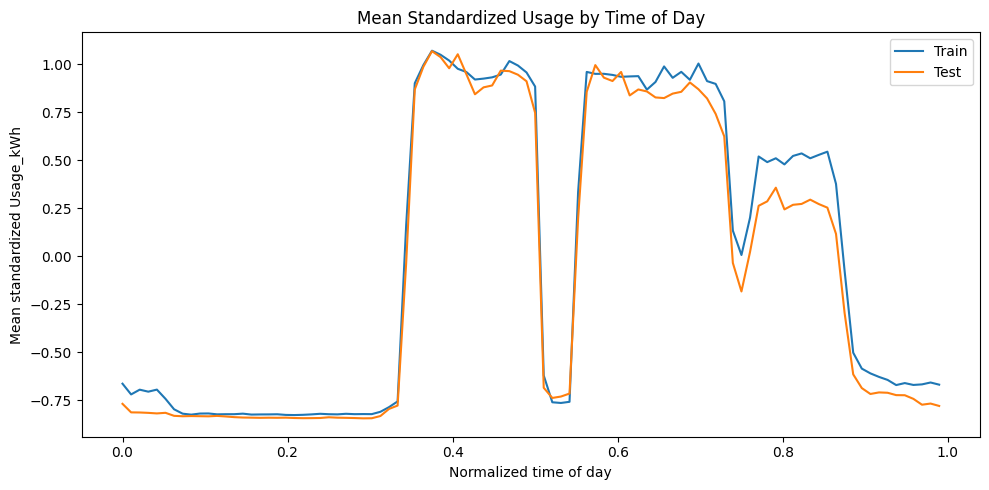

In [60]:
train_mean_by_time = (
    pd.DataFrame({"time": X_train.ravel(), "usage": y_train})
    .groupby("time", as_index=False)
    .mean()
)

test_mean_by_time = (
    pd.DataFrame({"time": X_test.ravel(), "usage": y_test})
    .groupby("time", as_index=False)
    .mean()
)

plt.figure(figsize=(10, 5))
plt.plot(train_mean_by_time["time"], train_mean_by_time["usage"], label="Train")
plt.plot(test_mean_by_time["time"], test_mean_by_time["usage"], label="Test")
plt.title("Mean Standardized Usage by Time of Day")
plt.xlabel("Normalized time of day")
plt.ylabel("Mean standardized Usage_kWh")
plt.legend()
plt.tight_layout()
plt.show()

Daily variance check

In [61]:
df["day"] = df["date"].dt.date

daily_variance = (
    df.groupby("day")["Usage_kWh"]
    .var()
    .reset_index()
    .rename(columns={"Usage_kWh": "daily_usage_variance"})
)

display(daily_variance.head())
print(f"Mean daily variance: {daily_variance['daily_usage_variance'].mean():.2f}")

,day,daily_usage_variance
0,2018-01-01,0.085524
1,2018-01-02,2146.579963
2,2018-01-03,1458.673208
3,2018-01-04,2724.591862
4,2018-01-05,2502.837954


Mean daily variance: 890.69


Kernel function

In [62]:

def rbf_kernel(X1, X2, lengthscale=1.0, signal_variance=1.0):
    X1 = np.asarray(X1)
    X2 = np.asarray(X2)

    squared_distance = (
        np.sum(X1 ** 2, axis=1, keepdims=True)
        + np.sum(X2 ** 2, axis=1)
        - 2 * X1 @ X2.T
    )

    return signal_variance * np.exp(-0.5 * squared_distance / lengthscale ** 2)


FITC sparse Gaussian Process prediction

In [63]:

def fitc_predict(
    X_train,
    y_train,
    Z,
    X_star,
    lengthscale=1.0,
    signal_variance=1.0,
    noise=0.1,
    jitter=1e-6,
):

    X_train = np.asarray(X_train)
    y_train = np.asarray(y_train)
    Z = np.asarray(Z)
    X_star = np.asarray(X_star)

    n = len(X_train)
    m = len(Z)

    K_mm = rbf_kernel(Z, Z, lengthscale, signal_variance)
    K_nm = rbf_kernel(X_train, Z, lengthscale, signal_variance)
    K_ms = rbf_kernel(Z, X_star, lengthscale, signal_variance)

    K_nn_diag = signal_variance * np.ones(n)

    L_m = np.linalg.cholesky(K_mm + jitter * np.eye(m))

    A = np.linalg.solve(L_m, K_nm.T)
    Q_nn_diag = np.sum(A ** 2, axis=0)

    Lambda = K_nn_diag - Q_nn_diag + noise
    Lambda = np.maximum(Lambda, jitter)

    B = K_nm.T / Lambda[np.newaxis, :]
    Sigma = K_mm + B @ K_nm
    Sigma = Sigma + jitter * np.eye(m)

    L_sigma = np.linalg.cholesky(Sigma)

    rhs = B @ y_train
    alpha = np.linalg.solve(L_sigma.T, np.linalg.solve(L_sigma, rhs))

    mu_star = K_ms.T @ alpha

    K_ss_diag = signal_variance * np.ones(len(X_star))

    V1 = np.linalg.solve(L_m, K_ms)
    V2 = np.linalg.solve(L_sigma, K_ms)

    var_star = K_ss_diag - np.sum(V1 ** 2, axis=0) + np.sum(V2 ** 2, axis=0)
    std_star = np.sqrt(np.maximum(var_star, 0.0))

    return mu_star, std_star


Utility functions

In [64]:
def choose_random_inducing_points(X, num_inducing_points=100, seed=0):
    """Choose random inducing points from X."""
    rng = np.random.default_rng(seed)
    m = min(num_inducing_points, len(X))
    idx = rng.choice(len(X), size=m, replace=False)
    return X[idx]


def choose_even_inducing_points(X, num_inducing_points=100):
    """Choose evenly spaced inducing points over the range of X."""
    m = min(num_inducing_points, len(X))
    return np.linspace(X.min(), X.max(), m).reshape(-1, 1)


def rmse(y_true, y_pred):
    """Root mean squared error."""
    return np.sqrt(mean_squared_error(y_true, y_pred))


def plot_prediction(X, y_true, mu, std, title):
    """Plot GP prediction with uncertainty."""
    plot_df = pd.DataFrame({
        "X": X.ravel(),
        "y_true": y_true,
        "mu": mu,
        "std": std,
    }).sort_values("X")

    plt.figure(figsize=(10, 5))
    plt.scatter(plot_df["X"], plot_df["y_true"], s=6, alpha=0.25, label="Test data")
    plt.plot(plot_df["X"], plot_df["mu"], linewidth=2, label="Prediction")
    plt.fill_between(
        plot_df["X"],
        plot_df["mu"] - 2 * plot_df["std"],
        plot_df["mu"] + 2 * plot_df["std"],
        alpha=0.15,
        label="±2σ interval",
    )
    plt.title(title)
    plt.xlabel("Normalized time of day")
    plt.ylabel("Standardized Usage_kWh")
    plt.legend()
    plt.tight_layout()
    plt.show()


def plot_weights(X, weights, expert_names, title):
    """Plot mixture-of-experts weights."""
    weight_df = pd.DataFrame({"X": X.ravel()})

    for j, name in enumerate(expert_names):
        weight_df[name] = weights[:, j]

    weight_df = weight_df.sort_values("X")

    plt.figure(figsize=(10, 4))

    for name in expert_names:
        plt.plot(weight_df["X"], weight_df[name], label=name)

    plt.title(title)
    plt.xlabel("Normalized time of day")
    plt.ylabel("Expert weight")
    plt.legend()
    plt.tight_layout()
    plt.show()

Grid search

In [65]:

def grid_search_gp(
    X_subtrain,
    y_subtrain,
    X_val,
    y_val,
    Z,
    lengthscale_grid,
    noise_grid,
    signal_variance_grid,
):
    """
    Simple grid search for sparse GP hyperparameters.
    """
    best_score = np.inf
    best_params = None

    for lengthscale, noise, signal_variance in product(
        lengthscale_grid,
        noise_grid,
        signal_variance_grid,
    ):
        try:
            mu_val, _ = fitc_predict(
                X_subtrain,
                y_subtrain,
                Z,
                X_val,
                lengthscale=lengthscale,
                signal_variance=signal_variance,
                noise=noise,
            )

            score = mean_squared_error(y_val, mu_val)

            if score < best_score:
                best_score = score
                best_params = {
                    "lengthscale": lengthscale,
                    "noise": noise,
                    "signal_variance": signal_variance,
                }

        except np.linalg.LinAlgError:
            continue

    return best_params, best_score


Tune one sparse GP per load type

In [66]:
tuning_results = {}

for load_type in np.unique(load_type_train):
    print(f"\nTuning GP for {load_type}")

    train_mask = load_type_train == load_type
    test_mask = load_type_test == load_type

    X_group = X_train[train_mask]
    y_group = y_train[train_mask]

    X_group_test = X_test[test_mask]
    y_group_test = y_test[test_mask]

    if len(X_group) < MIN_POINTS_PER_GP:
        print(f"Skipping {load_type}: only {len(X_group)} training rows")
        continue

    split_idx = int(0.8 * len(X_group))

    X_subtrain = X_group[:split_idx]
    y_subtrain = y_group[:split_idx]

    X_val = X_group[split_idx:]
    y_val = y_group[split_idx:]

    Z = choose_even_inducing_points(X_subtrain, NUM_INDUCING_POINTS)

    best_params, best_score = grid_search_gp(
        X_subtrain,
        y_subtrain,
        X_val,
        y_val,
        Z,
        LS_GRID,
        NOISE_GRID,
        SV_GRID,
    )

    if best_params is None:
        print(f"No stable parameters found for {load_type}")
        continue

    mu_test, std_test = fitc_predict(
        X_group,
        y_group,
        Z,
        X_group_test,
        lengthscale=best_params["lengthscale"],
        signal_variance=best_params["signal_variance"],
        noise=best_params["noise"],
    )

    test_rmse = rmse(y_group_test, mu_test)

    tuning_results[load_type] = {
        "params": best_params,
        "validation_mse": best_score,
        "test_rmse": test_rmse,
        "n_train": len(X_group),
        "n_test": len(X_group_test),
    }

    print(f"Best params: {best_params}")
    print(f"Validation MSE: {best_score:.4f}")
    print(f"Test RMSE: {test_rmse:.4f}")


Tuning GP for Light_Load
Best params: {'lengthscale': 0.01, 'noise': 0.05, 'signal_variance': 2.0}
Validation MSE: 0.0615
Test RMSE: 0.2265

Tuning GP for Maximum_Load
Best params: {'lengthscale': 0.01, 'noise': 0.2, 'signal_variance': 0.5}
Validation MSE: 0.4480
Test RMSE: 0.8635

Tuning GP for Medium_Load
Best params: {'lengthscale': 0.01, 'noise': 0.2, 'signal_variance': 0.5}
Validation MSE: 0.3323
Test RMSE: 0.6841


Display tuning results

In [67]:
tuning_summary = pd.DataFrame.from_dict(tuning_results, orient="index")
display(tuning_summary)

,params,validation_mse,test_rmse,n_train,n_test
Light_Load,"{'lengthscale': 0.01, 'noise': 0.05, 'signal_v...",0.061461,0.226493,8936,2232
Maximum_Load,"{'lengthscale': 0.01, 'noise': 0.2, 'signal_va...",0.448046,0.863493,4728,1224
Medium_Load,"{'lengthscale': 0.01, 'noise': 0.2, 'signal_va...",0.332336,0.684145,6304,1632


Train sparse GP experts

In [68]:

experts = {}
expert_names = []

for load_type, result in tuning_results.items():
    print(f"\nTraining expert for {load_type}")

    train_mask = load_type_train == load_type

    X_group = X_train[train_mask]
    y_group = y_train[train_mask]

    if len(X_group) < MIN_POINTS_PER_GP:
        print(f"Skipping {load_type}: only {len(X_group)} training rows")
        continue

    Z = choose_even_inducing_points(X_group, NUM_INDUCING_POINTS)

    experts[load_type] = {
        "X_train": X_group,
        "y_train": y_group,
        "Z": Z,
        "params": result["params"],
        "center": float(np.mean(X_group)),
        "n_train": len(X_group),
        "n_inducing": len(Z),
    }

    expert_names.append(load_type)

print("\nExperts trained:")

for name, info in experts.items():
    print(
        f"{name}: "
        f"{info['n_train']} rows, "
        f"{info['n_inducing']} inducing points, "
        f"center={info['center']:.3f}, "
        f"params={info['params']}"
    )


Training expert for Light_Load

Training expert for Maximum_Load

Training expert for Medium_Load

Experts trained:
Light_Load: 8936 rows, 150 inducing points, center=0.276, params={'lengthscale': 0.01, 'noise': 0.05, 'signal_variance': 2.0}
Maximum_Load: 4728 rows, 150 inducing points, center=0.599, params={'lengthscale': 0.01, 'noise': 0.2, 'signal_variance': 0.5}
Medium_Load: 6304 rows, 150 inducing points, center=0.726, params={'lengthscale': 0.01, 'noise': 0.2, 'signal_variance': 0.5}


Predict each expert on every test point

In [69]:
n_test = len(X_test)
n_experts = len(expert_names)

mu_experts = np.zeros((n_test, n_experts))
std_experts = np.zeros((n_test, n_experts))

for j, name in enumerate(expert_names):
    info = experts[name]
    params = info["params"]

    mu_j, std_j = fitc_predict(
        info["X_train"],
        info["y_train"],
        info["Z"],
        X_test,
        lengthscale=params["lengthscale"],
        signal_variance=params["signal_variance"],
        noise=params["noise"],
    )

    mu_experts[:, j] = mu_j
    std_experts[:, j] = std_j

print("mu_experts shape:", mu_experts.shape)
print("std_experts shape:", std_experts.shape)


mu_experts shape: (5088, 3)
std_experts shape: (5088, 3)


Method 1: distance-based soft gating

In [70]:
temperature = 0.005

centers = np.array([experts[name]["center"] for name in expert_names])

dist2 = (X_test.ravel()[:, None] - centers[None, :]) ** 2
logits = -dist2 / temperature

logits = logits - logits.max(axis=1, keepdims=True)
distance_weights = np.exp(logits)
distance_weights = distance_weights / distance_weights.sum(axis=1, keepdims=True)

Combine predictions using distance-based gating

In [71]:

mu_distance_mix = np.sum(distance_weights * mu_experts, axis=1)

var_experts = std_experts ** 2

within_uncertainty = np.sum(distance_weights * var_experts, axis=1)

disagreement = (
    np.sum(distance_weights * mu_experts ** 2, axis=1)
    - mu_distance_mix ** 2
)

var_distance_mix = within_uncertainty + BETA * disagreement
std_distance_mix = np.sqrt(np.maximum(var_distance_mix, 0.0))
std_distance_mix = np.minimum(std_distance_mix, STD_CLIP)

distance_mix_rmse = rmse(y_test, mu_distance_mix)

print(f"Distance-gated mixture RMSE: {distance_mix_rmse:.4f}")

print("\nAverage distance-based weights:")
for j, name in enumerate(expert_names):
    print(f"{name}: {distance_weights[:, j].mean():.3f}")

Distance-gated mixture RMSE: 0.6982

Average distance-based weights:
Light_Load: 0.443
Maximum_Load: 0.225
Medium_Load: 0.332


Plot distance-based mixture prediction

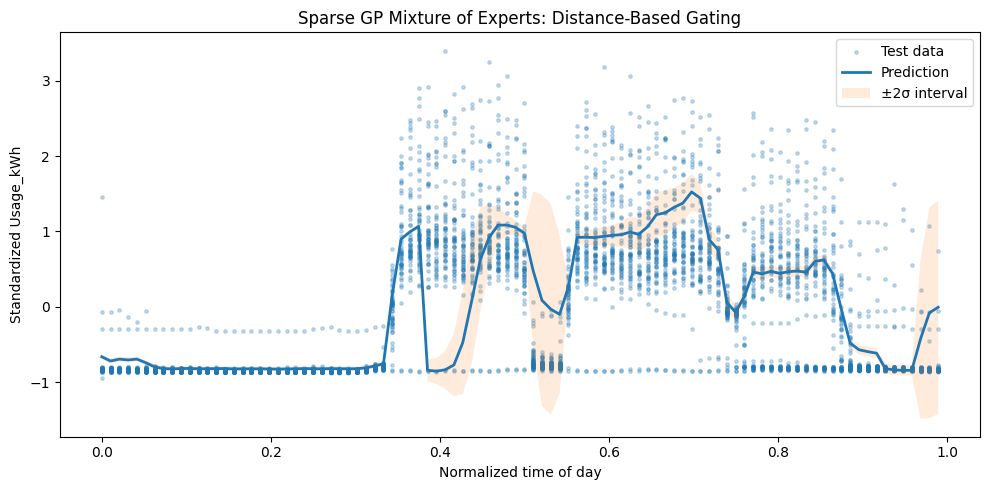

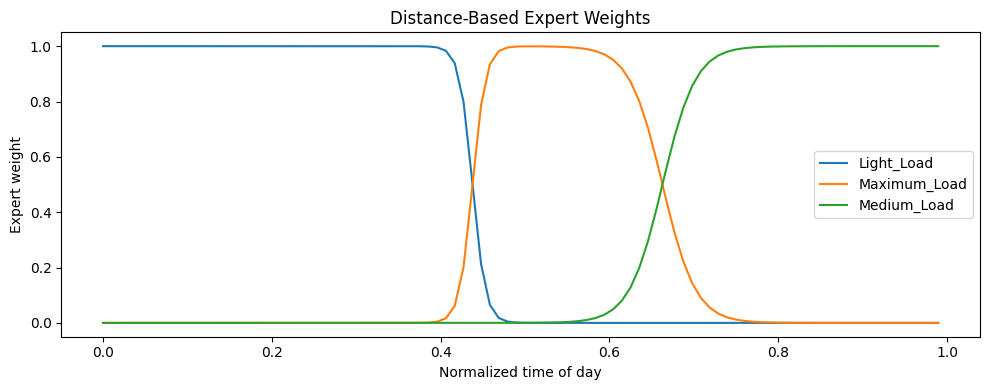

In [72]:
plot_prediction(
    X_test,
    y_test,
    mu_distance_mix,
    std_distance_mix,
    "Sparse GP Mixture of Experts: Distance-Based Gating",
)

plot_weights(
    X_test,
    distance_weights,
    expert_names,
    "Distance-Based Expert Weights",
)

Method 2: learned logistic-regression gating

In [73]:

gating_model = make_pipeline(
    StandardScaler(),
    LogisticRegression(
        multi_class="multinomial",
        max_iter=1000,
        random_state=RANDOM_SEED,
    ),
)

gating_model.fit(X_train, load_type_train)

all_class_names = gating_model.named_steps["logisticregression"].classes_
all_weights = gating_model.predict_proba(X_test)

learned_weights = np.zeros((len(X_test), len(expert_names)))

for j, expert_name in enumerate(expert_names):
    class_idx = np.where(all_class_names == expert_name)[0][0]
    learned_weights[:, j] = all_weights[:, class_idx]

learned_weights = learned_weights / learned_weights.sum(axis=1, keepdims=True)


Combine predictions using learned gating

In [74]:
mu_learned_mix = np.sum(learned_weights * mu_experts, axis=1)

within_uncertainty = np.sum(learned_weights * var_experts, axis=1)

disagreement = (
    np.sum(learned_weights * mu_experts ** 2, axis=1)
    - mu_learned_mix ** 2
)

var_learned_mix = within_uncertainty + BETA * disagreement
std_learned_mix = np.sqrt(np.maximum(var_learned_mix, 0.0))
std_learned_mix = np.minimum(std_learned_mix, STD_CLIP)

learned_mix_rmse = rmse(y_test, mu_learned_mix)

print(f"Learned-gating mixture RMSE: {learned_mix_rmse:.4f}")

print("\nAverage learned weights:")
for j, name in enumerate(expert_names):
    print(f"{name}: {learned_weights[:, j].mean():.3f}")


Learned-gating mixture RMSE: 0.6661

Average learned weights:
Light_Load: 0.448
Maximum_Load: 0.237
Medium_Load: 0.316


Plot learned-gating mixture prediction

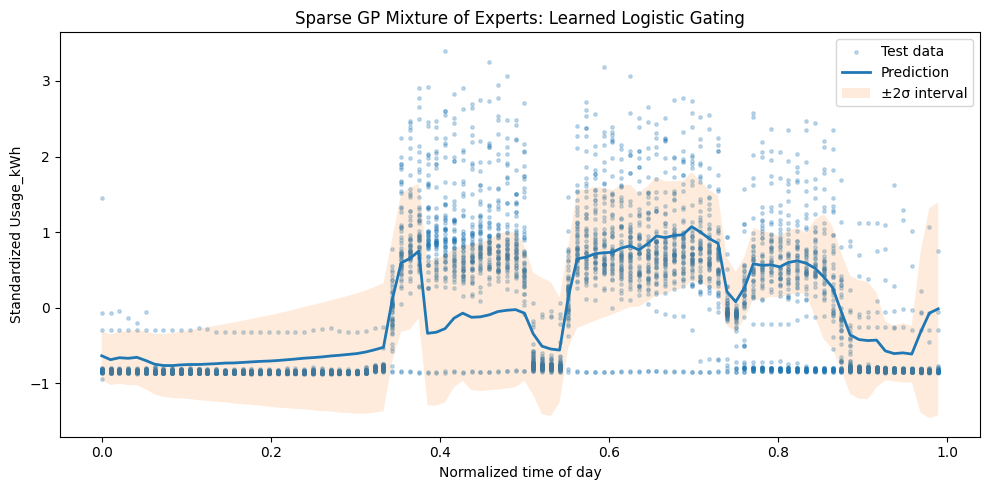

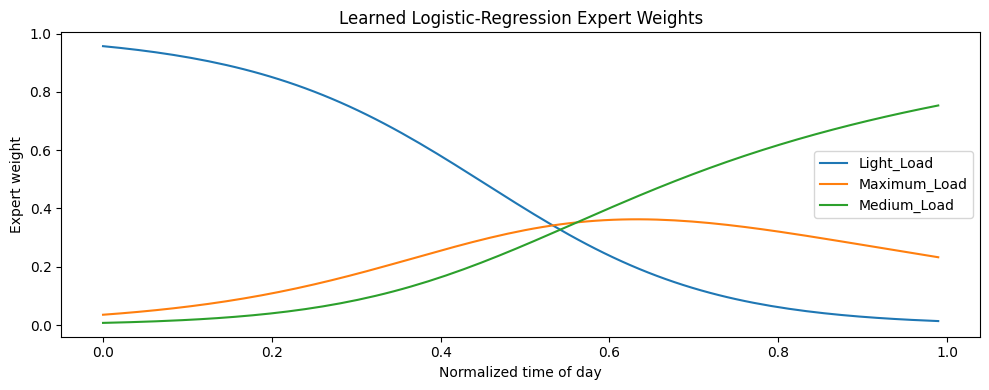

In [75]:
plot_prediction(
    X_test,
    y_test,
    mu_learned_mix,
    std_learned_mix,
    "Sparse GP Mixture of Experts: Learned Logistic Gating",
)

plot_weights(
    X_test,
    learned_weights,
    expert_names,
    "Learned Logistic-Regression Expert Weights",
)


Compare final models

In [76]:

comparison = pd.DataFrame([
    {
        "model": "Distance-gated sparse GP mixture",
        "rmse": distance_mix_rmse,
        "num_experts": len(expert_names),
        "beta": BETA,
    },
    {
        "model": "Learned-gating sparse GP mixture",
        "rmse": learned_mix_rmse,
        "num_experts": len(expert_names),
        "beta": BETA,
    },
])

display(comparison.sort_values("rmse"))


,model,rmse,num_experts,beta
1,Learned-gating sparse GP mixture,0.666121,3,0.2
0,Distance-gated sparse GP mixture,0.698191,3,0.2


Convert predictions back to original kWh scale

In [77]:

results_original_scale = pd.DataFrame({
    "date": test_df["date"].values,
    "time_normalized": X_test.ravel(),
    "actual_kWh": y_test * y_std + y_mean,
    "distance_mix_pred_kWh": mu_distance_mix * y_std + y_mean,
    "learned_mix_pred_kWh": mu_learned_mix * y_std + y_mean,
    "load_type": load_type_test,
})

display(results_original_scale.head())

,date,time_normalized,actual_kWh,distance_mix_pred_kWh,learned_mix_pred_kWh,load_type
0,2018-10-18 00:00:00,0.000000,3.64,10.199658,11.235713,Light_Load
1,2018-10-18 00:15:00,0.010417,4.72,8.176230,9.376783,Light_Load
2,2018-10-18 00:30:00,0.020833,4.00,9.071411,10.310039,Light_Load
3,2018-10-18 00:45:00,0.031250,3.49,8.695411,10.038554,Light_Load
4,2018-10-18 01:00:00,0.041667,3.60,9.082923,10.495915,Light_Load


Plot learned-gating predictions on original kWh scale

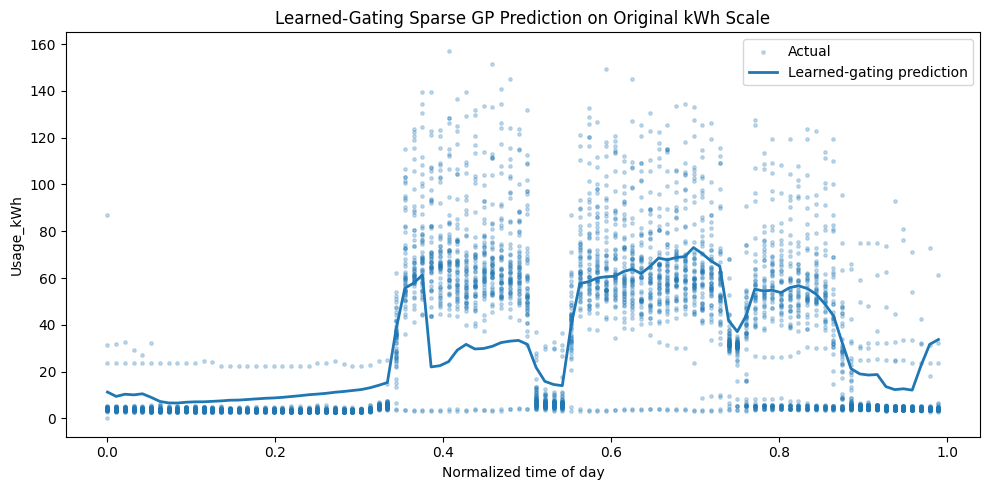

In [78]:
plot_original = results_original_scale.sort_values("time_normalized")

plt.figure(figsize=(10, 5))
plt.scatter(
    plot_original["time_normalized"],
    plot_original["actual_kWh"],
    s=6,
    alpha=0.25,
    label="Actual",
)
plt.plot(
    plot_original["time_normalized"],
    plot_original["learned_mix_pred_kWh"],
    linewidth=2,
    label="Learned-gating prediction",
)
plt.title("Learned-Gating Sparse GP Prediction on Original kWh Scale")
plt.xlabel("Normalized time of day")
plt.ylabel("Usage_kWh")
plt.legend()
plt.tight_layout()
plt.show()

Save results


In [79]:
results_original_scale.to_csv("sparse_gp_mixture_results.csv", index=False)
comparison.to_csv("sparse_gp_model_comparison.csv", index=False)

print("Saved:")
print("- sparse_gp_mixture_results.csv")
print("- sparse_gp_model_comparison.csv")

Saved:
- sparse_gp_mixture_results.csv
- sparse_gp_model_comparison.csv


In [80]:
# --- GPyTorch variational sparse GP replacement for FITC ---

!pip install gpytorch -q

import torch
import gpytorch

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")


class VariationalSparseGP(gpytorch.models.ApproximateGP):
    def __init__(self, inducing_points):
        variational_distribution = gpytorch.variational.CholeskyVariationalDistribution(
            inducing_points.size(0)
        )

        variational_strategy = gpytorch.variational.VariationalStrategy(
            self,
            inducing_points,
            variational_distribution,
            learn_inducing_locations=True,
        )

        super().__init__(variational_strategy)

        self.mean_module = gpytorch.means.ConstantMean()
        self.covar_module = gpytorch.kernels.ScaleKernel(
            gpytorch.kernels.RBFKernel()
        )

    def forward(self, x):
        mean_x = self.mean_module(x)
        covar_x = self.covar_module(x)
        return gpytorch.distributions.MultivariateNormal(mean_x, covar_x)


def train_variational_gp(
    X_train_np,
    y_train_np,
    Z_np,
    training_iter=500,
    lr=0.01,
):
    X_t = torch.tensor(X_train_np, dtype=torch.float32, device=DEVICE)
    y_t = torch.tensor(y_train_np, dtype=torch.float32, device=DEVICE)
    Z_t = torch.tensor(Z_np, dtype=torch.float32, device=DEVICE)

    model = VariationalSparseGP(Z_t).to(DEVICE)
    likelihood = gpytorch.likelihoods.GaussianLikelihood().to(DEVICE)

    model.train()
    likelihood.train()

    optimizer = torch.optim.Adam(
        list(model.parameters()) + list(likelihood.parameters()),
        lr=lr,
    )

    # Replacement for exact/FITC-style marginal likelihood
    mll = gpytorch.mlls.VariationalELBO(
        likelihood,
        model,
        num_data=y_t.numel(),
    )

    for i in range(training_iter):
        optimizer.zero_grad()
        output = model(X_t)
        loss = -mll(output, y_t)
        loss.backward()
        optimizer.step()

        if (i + 1) % 100 == 0:
            print(f"Iter {i + 1}/{training_iter} - Loss: {loss.item():.4f}")

    return model, likelihood


def variational_gp_predict(model, likelihood, X_star_np):
    X_star_t = torch.tensor(X_star_np, dtype=torch.float32, device=DEVICE)

    model.eval()
    likelihood.eval()

    with torch.no_grad(), gpytorch.settings.fast_pred_var():
        pred = likelihood(model(X_star_t))

    mu = pred.mean.cpu().numpy()
    std = pred.stddev.cpu().numpy()

    return mu, std

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 291.2/291.2 kB 6.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 174.8/174.8 kB 10.5 MB/s eta 0:00:00


In [81]:
experts = {}
expert_names = []

for load_type in np.unique(load_type_train):
    print(f"\nTraining variational GP expert for {load_type}")

    train_mask = load_type_train == load_type

    X_group = X_train[train_mask]
    y_group = y_train[train_mask]

    if len(X_group) < MIN_POINTS_PER_GP:
        print(f"Skipping {load_type}: only {len(X_group)} training rows")
        continue

    Z = choose_even_inducing_points(X_group, NUM_INDUCING_POINTS)

    model, likelihood = train_variational_gp(
        X_group,
        y_group,
        Z,
        training_iter=500,
        lr=0.01,
    )

    experts[load_type] = {
        "model": model,
        "likelihood": likelihood,
        "center": float(np.mean(X_group)),
        "n_train": len(X_group),
        "n_inducing": len(Z),
    }

    expert_names.append(load_type)


Training variational GP expert for Light_Load
Iter 100/500 - Loss: 0.8849
Iter 200/500 - Loss: 0.7060
Iter 300/500 - Loss: 0.5199
Iter 400/500 - Loss: 0.4414
Iter 500/500 - Loss: 0.4234

Training variational GP expert for Maximum_Load
Iter 100/500 - Loss: 1.1241
Iter 200/500 - Loss: 1.0921
Iter 300/500 - Loss: 1.0863
Iter 400/500 - Loss: 1.0797
Iter 500/500 - Loss: 1.0712

Training variational GP expert for Medium_Load
Iter 100/500 - Loss: 1.3348
Iter 200/500 - Loss: 1.2742
Iter 300/500 - Loss: 1.2303
Iter 400/500 - Loss: 1.0483
Iter 500/500 - Loss: 1.0318


In [82]:
n_test = len(X_test)
n_experts = len(expert_names)

mu_experts = np.zeros((n_test, n_experts))
std_experts = np.zeros((n_test, n_experts))

for j, name in enumerate(expert_names):
    info = experts[name]

    mu_j, std_j = variational_gp_predict(
        info["model"],
        info["likelihood"],
        X_test,
    )

    mu_experts[:, j] = mu_j
    std_experts[:, j] = std_j

print("mu_experts shape:", mu_experts.shape)
print("std_experts shape:", std_experts.shape)

mu_experts shape: (5088, 3)
std_experts shape: (5088, 3)


In [83]:
# --- Evaluation cell for variational GP mixture ---

def evaluate_model(name, y_true, y_pred, std_pred=None):
    rmse_val = rmse(y_true, y_pred)
    mse_val = mean_squared_error(y_true, y_pred)

    print(f"\n{name}")
    print(f"RMSE: {rmse_val:.4f}")
    print(f"MSE:  {mse_val:.4f}")

    if std_pred is not None:
        # Negative log likelihood (Gaussian assumption)
        var = np.maximum(std_pred**2, 1e-6)
        nll = 0.5 * np.mean(
            np.log(2 * np.pi * var) + (y_true - y_pred) ** 2 / var
        )
        print(f"NLL:  {nll:.4f}")

        # Coverage of 95% interval
        lower = y_pred - 2 * std_pred
        upper = y_pred + 2 * std_pred
        coverage = np.mean((y_true >= lower) & (y_true <= upper))
        print(f"95% interval coverage: {coverage:.3f}")


# --- Evaluate individual experts ---
print("\n=== Individual Experts ===")

for j, name in enumerate(expert_names):
    evaluate_model(
        f"Expert: {name}",
        y_test,
        mu_experts[:, j],
        std_experts[:, j],
    )


# --- Evaluate mixtures ---
print("\n=== Mixture Models ===")

evaluate_model(
    "Distance-gated mixture",
    y_test,
    mu_distance_mix,
    std_distance_mix,
)

evaluate_model(
    "Learned-gating mixture",
    y_test,
    mu_learned_mix,
    std_learned_mix,
)


# --- Optional: comparison table ---
results_eval = []

def add_result(name, y_true, y_pred):
    results_eval.append({
        "model": name,
        "rmse": rmse(y_true, y_pred),
        "mse": mean_squared_error(y_true, y_pred),
    })

for j, name in enumerate(expert_names):
    add_result(f"Expert: {name}", y_test, mu_experts[:, j])

add_result("Distance mixture", y_test, mu_distance_mix)
add_result("Learned mixture", y_test, mu_learned_mix)

eval_df = pd.DataFrame(results_eval).sort_values("rmse")
display(eval_df)


=== Individual Experts ===

Expert: Light_Load
RMSE: 1.1447
MSE:  1.3104
NLL:  4.6751
95% interval coverage: 0.596

Expert: Maximum_Load
RMSE: 1.2034
MSE:  1.4481
NLL:  1.8334
95% interval coverage: 0.775

Expert: Medium_Load
RMSE: 1.2090
MSE:  1.4616
NLL:  1.7686
95% interval coverage: 0.843

=== Mixture Models ===

Distance-gated mixture
RMSE: 0.6982
MSE:  0.4875
NLL:  92.1856
95% interval coverage: 0.340

Learned-gating mixture
RMSE: 0.6661
MSE:  0.4437
NLL:  1.6374
95% interval coverage: 0.831


,model,rmse,mse
4,Learned mixture,0.666121,0.443717
3,Distance mixture,0.698191,0.487470
0,Expert: Light_Load,1.144710,1.310360
1,Expert: Maximum_Load,1.203356,1.448066
2,Expert: Medium_Load,1.208951,1.461562


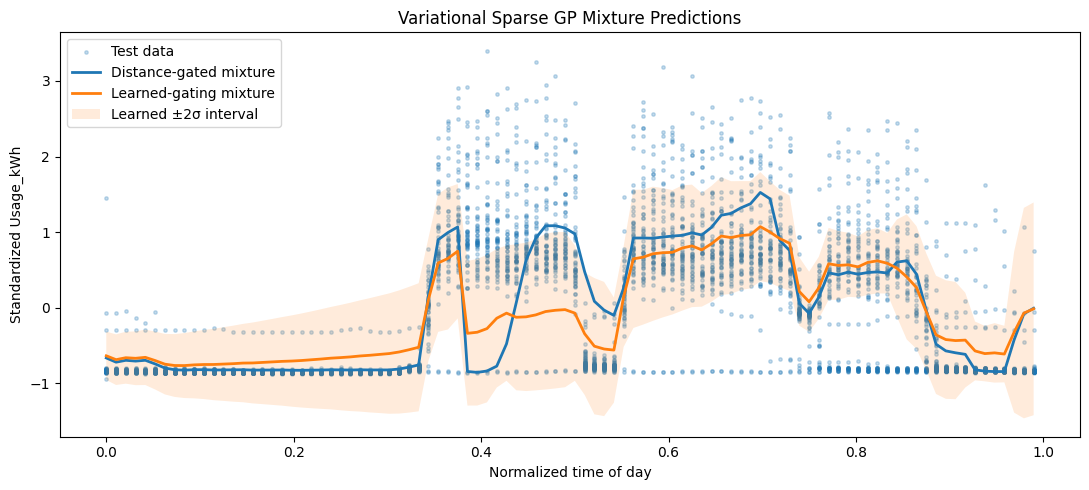

In [84]:
# --- Compare distance vs learned mixture predictions ---

plot_df = pd.DataFrame({
    "X": X_test.ravel(),
    "y_true": y_test,
    "distance_mu": mu_distance_mix,
    "distance_std": std_distance_mix,
    "learned_mu": mu_learned_mix,
    "learned_std": std_learned_mix,
}).sort_values("X")

plt.figure(figsize=(11, 5))
plt.scatter(plot_df["X"], plot_df["y_true"], s=6, alpha=0.25, label="Test data")

plt.plot(
    plot_df["X"],
    plot_df["distance_mu"],
    linewidth=2,
    label="Distance-gated mixture",
)

plt.plot(
    plot_df["X"],
    plot_df["learned_mu"],
    linewidth=2,
    label="Learned-gating mixture",
)

plt.fill_between(
    plot_df["X"],
    plot_df["learned_mu"] - 2 * plot_df["learned_std"],
    plot_df["learned_mu"] + 2 * plot_df["learned_std"],
    alpha=0.15,
    label="Learned ±2σ interval",
)

plt.title("Variational Sparse GP Mixture Predictions")
plt.xlabel("Normalized time of day")
plt.ylabel("Standardized Usage_kWh")
plt.legend()
plt.tight_layout()
plt.show()